# FashionMNIST 服装图像分类

本 Notebook 以 FashionMNIST 数据集为例，系统演示如何使用 PyTorch 构建、训练并评估一个全连接神经网络图像分类器。

**数据集简介**：FashionMNIST 是 Zalando 发布的服装图像数据集，共包含 10 类服装，60000 张训练图片和 10000 张测试图片，每张图片为 28×28 的灰度图像。

**内容结构**：
1. 环境配置与库导入
2. 数据可视化（灰度图展示）
3. 数据预处理（标准化 + DataLoader）
4. 定义全连接神经网络模型
5. 训练循环（损失函数 + 优化器 + 评估）
6. 绘制学习曲线
7. 最终评估

## 一、环境配置与库导入

导入本教程所需的全部第三方库，并检测当前运行环境（Python 版本、各库版本）以及可用的计算设备（CPU / GPU）。

In [1]:
import matplotlib as mpl  # 导入 matplotlib 库，用于数据可视化，别名为 mpl
import matplotlib.pyplot as plt  # 导入 matplotlib 的 pyplot 子模块，提供类 MATLAB 的绘图接口，别名为 plt
import numpy as np  # 导入 NumPy 数值计算库，别名为 np，用于高效的多维数组运算
import sklearn  # 导入 scikit-learn 机器学习工具库，用于计算准确率等评估指标
import pandas as pd  # 导入 Pandas 数据分析库，别名为 pd，用于构建 DataFrame 处理训练记录
import os  # 导入 os 模块，提供操作系统相关接口，如文件路径、目录操作
import sys  # 导入 sys 模块，提供 Python 运行时系统信息，如 sys.version_info
import time  # 导入 time 模块，提供时间测量和延时功能
from tqdm import tqdm  # 从 tqdm 导入 tqdm；auto 模式会自动选择适合当前环境（notebook/命令行）的进度条样式
import torch  # 导入 PyTorch 核心库，提供张量计算和自动微分功能
import torch.nn as nn  # 导入 PyTorch 神经网络模块，别名 nn，包含 Linear、ReLU、Flatten、Sequential 等网络层
import torch.nn.functional as F  # 导入 PyTorch 函数式 API，别名 F，提供无状态的激活函数、损失函数等
%matplotlib inline 
 # Jupyter 魔法命令：将生成的图表直接嵌入到 notebook 中显示，而非弹出独立窗口
# 打印当前 Python 版本详细信息
# 返回类型：sys.version_info 对象，包含 major（主版本）、minor（次版本）、micro（微版本）等属性
print(sys.version_info)
# 依次遍历各个库对象，打印其名称（__name__）和版本号（__version__）
# 用于确认运行环境中各依赖库的版本是否符合预期，便于复现实验
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)

# 自动检测计算设备：
#   - torch.cuda.is_available()：返回 bool，若系统存在可用的 GPU 则为 True
#   - torch.device("cuda:0")：使用第 0 块 GPU
#   - torch.device("cpu")：使用 CPU
# 后续所有张量和模型都应移动到该 device 上，以充分利用 GPU 加速
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
# 打印当前使用的设备名称，如 "cpu" 或 "cuda:0"
print(device)


sys.version_info(major=3, minor=14, micro=5, releaselevel='final', serial=0)
matplotlib 3.10.9
numpy 2.4.6
pandas 3.0.3
sklearn 1.9.0
torch 2.12.0+cu132
cuda:0


In [2]:
# FashionMNIST 中每张图像的尺寸为 28×28 像素（灰度图）
# 将图像展平（Flatten）为一维向量后，输入特征维度 = 28 * 28 = 784
# 这也是后面全连接层第一层输入维度为 784 的原因
28 * 28  # 计算 784，即展平后的输入特征数量

784

## 二、数据可视化准备

加载 **不含 ToTensor 变换** 的 FashionMNIST 数据集，此时每个样本返回的图像为 PIL Image 对象，可直接用于灰度图的可视化查看。

> **注意**：该步骤中 `transform=None`，图像以 PIL 格式（像素值范围 0-255）返回，不可直接用于模型训练。

### 2.1 数据集加载与探索

In [3]:
from torchvision import datasets  # 从 torchvision 导入内置数据集模块，包含 MNIST、FashionMNIST 等常用数据集
from torchvision.transforms import ToTensor  # 导入 ToTensor 变换，将 PIL Image 转换为 PyTorch Tensor 并归一化到 [0, 1]
from torchvision import transforms  # 导入 transforms 模块，提供图像预处理变换的组合工具

# 定义空的数据变换流水线（此处不做任何变换，保留 PIL Image 原始格式，方便后续可视化）
# transforms.Compose()：将多个变换按顺序组合，此处列表为空，即不做任何变换
transform = transforms.Compose([
])

# 加载 FashionMNIST 训练集
# 参数说明：
#   root (str)      : 数据集存储的根目录路径，若不存在则自动下载到该目录
#   train (bool)    : True 表示加载训练集（60000 张图片），False 表示加载测试集（10000 张图片）
#   download (bool) : True 表示若本地不存在数据集则自动从网络下载
#   transform       : 对每张图片应用的变换，None 表示不做变换，返回原始 PIL Image 对象
# 返回值：torchvision.datasets.FashionMNIST 对象，支持索引访问，每个元素为 (image, label) 元组
train_ds = datasets.FashionMNIST(
    root="data",    # 数据保存路径：当前目录下的 data 文件夹
    train=True,     # 加载训练集
    download=True,  # 若本地没有则自动下载
    transform=None  # 不做任何变换，返回 PIL.Image 对象（供可视化使用）
)

# 加载 FashionMNIST 测试集
# 参数说明同上，train=False 表示加载测试集（10000 张图片）
# 测试集通常用于模型的最终评估，不参与训练过程
test_ds = datasets.FashionMNIST(
    root="data",    # 数据保存路径
    train=False,    # 加载测试集
    download=True,  # 若本地没有则自动下载
    transform=None  # 不做任何变换
)

# 注意：torchvision 内置数据集未提供训练集和验证集的划分
# 若需要验证集，可使用 torch.utils.data.random_split() 或手动实现划分逻辑

100%|██████████| 26.4M/26.4M [00:16<00:00, 1.56MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 118kB/s]
100%|██████████| 4.42M/4.42M [00:02<00:00, 1.83MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 21.2MB/s]


In [4]:
# 查看训练集对象的类型
# 返回类型：type 对象，结果为 <class 'torchvision.datasets.mnist.FashionMNIST'>
# 说明 train_ds 是 FashionMNIST 类的实例，继承自 torch.utils.data.Dataset
type(train_ds)

torchvision.datasets.mnist.FashionMNIST

In [5]:
# 查看训练集的样本总数
# len() 对 Dataset 对象调用 __len__ 方法
# 返回类型：int，FashionMNIST 训练集共 60000 个样本
len(train_ds)  # 输出结果：60000（60000 张训练图片）

60000

In [6]:
# 通过索引访问数据集中第一个样本，查看其返回类型
# Dataset 支持下标访问，train_ds[0] 调用 __getitem__(0) 方法
# 返回类型：tuple，包含 (image, label) 两个元素
#   - image：PIL.Image.Image 对象（此时 transform=None，未做张量化处理）
#     · image.size      → (28, 28)，即 (宽, 高)，FashionMNIST 每张图为 28×28 像素
#     · image.mode      → 'L'，8-bit 灰度图（单通道），像素值范围 0~255
#     · np.array(image).shape → (28, 28)，转为 numpy 数组后无独立通道维度
#     · 经 ToTensor() 后  → torch.Size([1, 28, 28])，即 (C, H, W) = (1, 28, 28)
#     · 展平后维度        → 1 × 28 × 28 = 784，即全连接层第一层的输入维度
#   - label：int，表示类别标签（0~9）
type(train_ds[0])

tuple

In [7]:
# 通过索引取出数据集第一个样本，返回一个元组 (image, label)
# 在训练时通常将特征（图像）和标签分开处理
# img   类型：PIL.Image.Image（因为 transform=None，图像未转化为张量）
# label 类型：int，表示该图像对应的类别编号（0~9）
img, label = train_ds[0]

In [8]:
# 查看 img 的数据类型
# 由于 transform=None，图像以 PIL.Image.Image 格式返回
# 若设置 transform=ToTensor()，则会返回 torch.Tensor 类型的张量
# PIL.Image.Image 是 Python Imaging Library 中的图像对象，支持直接显示
type(img)  # 输出：<class 'PIL.Image.Image'>

PIL.Image.Image

In [9]:
# 在 Jupyter Notebook 中直接输出 PIL.Image.Image 对象，会自动渲染为图像
# img 为第一张训练样本的图像，是 28×28 的灰度图（mode='L'）
# 'L' 模式表示灰度（Luminance），像素值范围 0-255
img  # 显示图像：Jupyter 自动调用 PIL 图像的 _repr_png_ 等方法渲染图片

In [10]:
# 查看第一个样本的标签（类别编号）
# 返回类型：int，范围为 0~9，对应 10 种服装类别
# FashionMNIST 类别映射：
#   0: T-shirt/top, 1: Trouser, 2: Pullover, 3: Dress, 4: Coat,
#   5: Sandal, 6: Shirt, 7: Sneaker, 8: Bag, 9: Ankle boot
label  # 输出结果：9（表示 Ankle boot，踝靴）

9

### 2.2 数据集可视化

In [11]:
# 注意：此函数需要 transform=None 时才能正常运行
# 若设置了 ToTensor() 变换，img 将是 Tensor 而非 PIL Image，下面方法会报错

def show_img_content(img):
    """
    打印 PIL 图像的基本信息和像素值列表。
    
    参数：
        img (PIL.Image.Image)：待分析的图像对象，必须是 PIL 格式（非 Tensor）
    
    返回值：无（直接打印到控制台）
    """
    from PIL import Image  # 导入 PIL 的 Image 模块（本函数中已通过参数传入图像，此行备用）

    # img.size 返回元组 (width, height)，即图像的宽度和高度（像素）
    print("图像大小:", img.size)   # FashionMNIST 输出：(28, 28)
    # img.mode 返回图像模式字符串
    # 'L' 表示 8位灰度图，'RGB' 表示彩色图，'RGBA' 表示带透明通道的彩色图
    print("图像模式:", img.mode)   # FashionMNIST 输出：'L'（灰度图）

    # 对于灰度图（mode='L'），获取所有像素值组成的一维列表
    # img.get_flattened_data() 返回序列对象，list() 将其转换为 Python 列表
    # 列表长度 = 28 * 28 = 784，每个元素范围 0~255（0=黑色，255=白色）
    if img.mode == 'L':
        pixel_values = list(img.get_flattened_data())  # 获取所有像素值，返回 list[int]，长度为 784
        print(pixel_values)                 # 打印 784 个像素值

# 调用函数，传入 PIL Image 对象 img（注意：transform 必须设为 None）
show_img_content(img)  # 打印图像大小、模式和全部像素值

图像大小: (28, 28)
图像模式: L
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 13, 73, 0, 0, 1, 4, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 36, 136, 127, 62, 54, 0, 0, 0, 1, 3, 4, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 0, 102, 204, 176, 134, 144, 123, 23, 0, 0, 0, 0, 12, 10, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 155, 236, 207, 178, 107, 156, 161, 109, 64, 23, 77, 130, 72, 15, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 69, 207, 223, 218, 216, 216, 163, 127, 121, 122, 146, 141, 88, 172, 66, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 200, 232, 232, 233, 229, 223, 223, 215, 213, 164, 127, 123, 196, 229, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 183, 225, 216, 223, 228, 235, 227, 224, 222, 224, 221, 223, 245, 173, 0, 0, 0, 

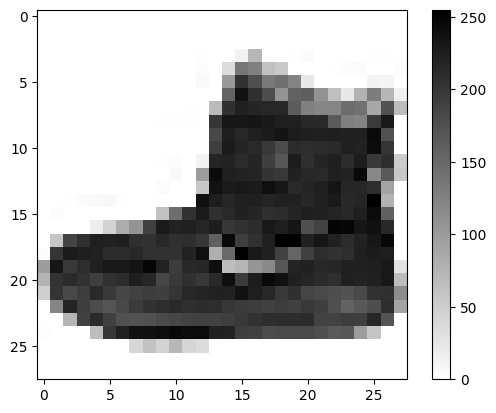

In [12]:
# 注意：此函数也需要在 transform=None 条件下运行，img 必须是 PIL Image 对象
# 若 img 是 Tensor（经过 ToTensor 变换），需先转换回 PIL 格式才能使用 plt.imshow

def show_single_image(img_arr):
    """
    使用 matplotlib 显示单张灰度图像，并附加颜色条。
    
    参数：
        img_arr (PIL.Image.Image 或 numpy.ndarray)：待显示的图像，支持 PIL 图像直接传入
    
    返回值：无（直接渲染图像到当前 matplotlib figure）
    """
    # plt.imshow()：将图像数据渲染为热力图或灰度图
    # 参数 img_arr：图像数据（PIL Image / NumPy array）
    # 参数 cmap="binary"：使用二值化灰度色图（0=白色，255=黑色，与自然灰度视觉相反）
    plt.imshow(img_arr, cmap="binary")  # 将图像以灰度形式显示（黑白图）
    # plt.colorbar()：在图像旁边添加颜色条，显示像素值 0-255 对应的颜色映射
    plt.colorbar()   # 显示颜色比例尺，便于理解灰度值含义
    # plt.show()：渲染并显示当前图形，在 Jupyter Notebook 中触发显示
    plt.show()       # 输出最终图像

# 传入 PIL Image 对象，显示第一张训练样本（踝靴）的灰度图
show_single_image(img)  # 显示 28×28 的灰度靴子图像

## 三、数据预处理与 DataLoader 构建

为模型训练做准备，需要对原始图像进行以下两步处理：
1. **ToTensor**：将 PIL Image 转换为 PyTorch Tensor，像素值从 [0, 255] 归一化到 [0, 1]
2. **Normalize**：使用数据集的均值和标准差对 Tensor 进行标准化，使数据分布接近标准正态分布，有助于加速训练

### 3.1 数据预处理与归一化

In [13]:
from torchvision import datasets          # 导入 torchvision 内置数据集模块
from torchvision.transforms import ToTensor  # 导入 ToTensor 变换
from torchvision import transforms           # 导入变换组合工具

# FashionMNIST 训练集的统计参数（通过 cal_mean_std 函数预先计算得到）
# mean（均值）：用于标准化，将数据中心化
# std（标准差）：用于标准化，将数据缩放到单位方差
mean = 0.2860  # FashionMNIST 训练集图像的全局像素均值（经过 ToTensor 归一化到 [0,1] 后的均值）
std = 0.3205   # FashionMNIST 训练集图像的全局像素标准差

# 定义图像预处理流水线（变换链），按顺序依次执行：
# 步骤 1：ToTensor()  → 将 PIL Image 转换为 torch.Tensor
#          形状从 (H, W) 变为 (C, H, W) = (1, 28, 28)，像素值从 [0,255] 归一化到 [0.0, 1.0]
# 步骤 2：Normalize(mean, std) → 对 Tensor 进行 Z-score 标准化：(x - mean) / std
#          使数据分布接近均值为 0、方差为 1 的标准正态分布，有助于加速梯度下降收敛
transform = transforms.Compose([
    transforms.ToTensor(),           # 将 PIL Image 转为 Tensor，形状：(1, 28, 28)，值域：[0.0, 1.0]
    transforms.Normalize(mean, std)  # 标准化：(像素值 - mean) / std，使特征分布稳定
])

# 加载带变换的 FashionMNIST 训练集（用于模型训练）
# 每次访问元素时，transform 会被自动应用到图像上
# 返回的 img 此时为 torch.Tensor，形状为 (1, 28, 28)，值域经过标准化
train_ds = datasets.FashionMNIST(
    root="data",         # 数据存储根目录
    train=True,          # 加载训练集（60000 张）
    download=True,       # 若本地不存在则自动下载
    transform=transform
)

test_ds = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

# torchvision 数据集里没有提供训练集和验证集的划分
# 当然也可以用 torch.utils.data.Dataset 实现人为划分

In [14]:
# 取出训练集第一个样本，解包为图像张量和标签
# img_tensor 类型：torch.Tensor，经过 ToTensor + Normalize 变换后的图像
# label      类型：int，类别编号（0~9）
img_tensor, label = train_ds[0]

# 查看图像张量的形状
# 返回类型：torch.Size 对象，可作为元组使用
# 形状含义：(通道数 C, 高度 H, 宽度 W) = (1, 28, 28)
#   C=1：灰度图只有 1 个通道（彩色图 RGB 为 3 通道）
#   H=28, W=28：每张图像 28×28 像素
img_tensor.shape  # 输出：torch.Size([1, 28, 28])

torch.Size([1, 28, 28])

In [15]:
# 查看经过变换后的图像数据类型
# 由于 transform 中包含 ToTensor()，img_tensor 已从 PIL Image 转换为 PyTorch 张量
# 返回类型：type 对象，结果为 <class 'torch.Tensor'>
# torch.Tensor 是 PyTorch 的核心数据结构，类似 NumPy 的 ndarray，支持 GPU 加速
type(img_tensor)  # 输出：<class 'torch.Tensor'>

torch.Tensor

In [16]:
# 查看第一个样本的标签（与上面可视化部分相同，标签为整数类别编号）
# 返回类型：int，值为 9，对应 Ankle boot（踝靴）
label  # 输出：9

9

In [17]:
# 计算数据集所有图像的均值（mean）和标准差（std），用于后续 Normalize 变换
# 注意：在调用此函数之前，数据集应已应用 ToTensor() 变换（像素值范围 [0,1]）

def cal_mean_std(ds):
    """
    遍历数据集，计算所有图像的逐通道均值和标准差。
    
    参数：
        ds (torch.utils.data.Dataset)：已应用 ToTensor 变换的数据集对象，
                                       每个元素为 (image_tensor, label) 元组
    
    返回值：
        mean (torch.Tensor)：形状为 (C,)，每个通道的平均像素值（对全体图像求平均）
        std  (torch.Tensor)：形状为 (C,)，每个通道的像素标准差（对全体图像求平均）
    """
    mean = 0.  # 初始化均值累加器（float 类型）
    std = 0.   # 初始化标准差累加器（float 类型）
    # 遍历数据集中的每张图像
    # img 的形状为 (C, H, W) = (1, 28, 28)，_（下划线）表示忽略标签
    for img, _ in ds:
        # img.mean(dim=(1, 2))：对第 1 维（H=高度）和第 2 维（W=宽度）求平均
        # 即对每个通道的所有像素求均值，返回形状为 (C,) 的张量
        # 对于灰度图（C=1），结果是包含 1 个元素的张量
        mean += img.mean(dim=(1, 2))  # 累加当前图像的逐通道均值，返回 torch.Tensor，形状 (1,)
        # img.std(dim=(1, 2))：对每个通道的所有像素求标准差，返回形状 (C,) 的张量
        std += img.std(dim=(1, 2))   # 累加当前图像的逐通道标准差，返回 torch.Tensor，形状 (1,)
    # 除以样本总数，得到数据集级别的平均均值和平均标准差
    # 注意：这是"先对每张图求均值，再对所有图的均值求平均"的近似方法
    mean /= len(ds)  # 整体平均均值，类型：torch.Tensor，形状 (1,)
    std /= len(ds)   # 整体平均标准差，类型：torch.Tensor，形状 (1,)
    return mean, std  # 返回元组 (mean, std)，均为 torch.Tensor

# 调用函数计算训练集的统计参数
# 输出结果约为 (tensor([0.2860]), tensor([0.3205]))，与前面设置的 mean=0.2860, std=0.3205 对应
print(cal_mean_std(train_ds))


(tensor([0.0001]), tensor([0.9999]))


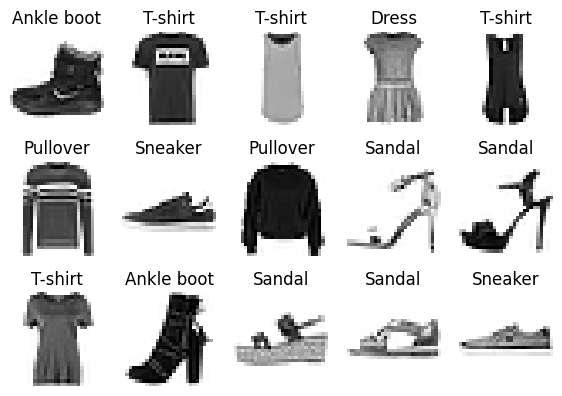

In [18]:
def show_imgs(n_rows, n_cols, train_ds, class_names):
    """
    以网格形式显示数据集中的多张图像及其类别标签。
    
    参数：
        n_rows     (int)  : 网格行数，决定显示多少行图像
        n_cols     (int)  : 网格列数，决定显示多少列图像
        train_ds   (Dataset)   : 数据集对象，每个元素为 (image_tensor, label) 元组
        class_names (list[str]): 类别名称列表，索引对应标签编号 0~9
    
    返回值：无（直接渲染 matplotlib 图形）
    """
    # 断言检查：确保要显示的图片数量不超过数据集大小
    assert n_rows * n_cols < len(train_ds), "要显示的图片数量超过数据集大小！"
    # 创建 matplotlib 画布：总宽度 = n_cols * 1.4 英寸，总高度 = n_rows * 1.6 英寸
    plt.figure(figsize=(n_cols * 1.4, n_rows * 1.6))  # 设置画布大小（单位：英寸）
    # 双重循环遍历网格的每个位置
    for row in range(n_rows):   # 遍历行，range(n_rows) 从 0 到 n_rows-1
        for col in range(n_cols):  # 遍历列，range(n_cols) 从 0 到 n_cols-1
            # 计算当前格子对应的数据集索引（从 0 开始线性排列）
            index = n_cols * row + col  # 例如 n_cols=5 时：第1行第2列 → index=1
            # plt.subplot(rows, cols, index)：创建子图，index 从 1 开始计数
            plt.subplot(n_rows, n_cols, index + 1)  # 注意：subplot 的 index 从 1 开始
            # 从数据集取出第 index 个样本的图像张量和标签
            img_arr, label = train_ds[index]  # img_arr: torch.Tensor，形状 (1, 28, 28)
            # matplotlib 的 imshow 需要图像形状为 (H, W, C) 或 (H, W)
            # 原始 img_arr 形状为 (C, H, W) = (1, 28, 28)，需要转置
            # np.transpose(arr, (1, 2, 0))：将轴顺序从 (0,1,2) 重排为 (1,2,0)
            # 即 (C, H, W) → (H, W, C) = (28, 28, 1)，满足 imshow 的输入格式
            img_arr = np.transpose(img_arr, (1, 2, 0))  # 调整轴顺序，结果形状：(28, 28, 1)
            # plt.imshow()：显示图像
            # cmap="binary"：使用二值灰度色图（0=白，255=黑）
            # interpolation='nearest'：使用最近邻插值，保留原始像素，避免模糊
            plt.imshow(img_arr, cmap="binary", interpolation='nearest')  # 显示灰度图
            plt.axis('off')                  # 隐藏坐标轴，使图像更简洁
            plt.title(class_names[label])    # 在子图上方显示对应的类别名称
    plt.show()  # 渲染并显示整个图形

# FashionMNIST 的 10 个类别名称（按标签编号 0~9 排列）
# 来源：https://github.com/zalandoresearch/fashion-mnist
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress',
               'Coat', 'Sandal', 'Shirt', 'Sneaker',
               'Bag', 'Ankle boot']  # 列表索引 0~9 分别对应 10 种服装类别

# 调用函数显示训练集前 15（3行×5列）张样本的图像和类别
show_imgs(3, 5, train_ds, class_names)  # 显示 3 行 5 列共 15 张图像


### 3.2 构建 DataLoader

In [19]:
from torch.utils.data import random_split
import os
# torch.utils.data.DataLoader 完整参数说明：
#   dataset            (Dataset)         : 数据集对象，需实现 __len__ 和 __getitem__，每个元素通常为 (image_tensor, label) 元组
#   batch_size         (int)             : 每个批次包含的样本数量，默认为 1。例如 batch_size=32 时，每个 batch 提供 32 张图像
#                                          总迭代次数 = 样本总数 / batch_size，例如 60000 / 32 ≈ 1875 次/epoch
#   shuffle            (bool)            : 是否在每个 epoch 开始时打乱样本顺序，默认 False。
#                                          训练集通常设为 True 以防止模型记忆数据顺序；设置 sampler 后此参数必须为 False，两者互斥
#   num_workers        (int)             : 使用的数据加载子进程数量，默认为 0（只用主进程）。>0 可并行加载数据加速训练，
#                                          建议根据 CPU 核心数和 I/O 瓶颈调整，Windows 下多进程需在 if __name__=='__main__' 中运行
#   drop_last          (bool)            : 若样本总数不能被 batch_size 整除，是否丢弃最后一个不满 batch，默认 False。
#                                          训练时可设为 True 保持每批大小一致；验证/测试集通常设 False 确保所有样本被评估
#   pin_memory         (bool)            : 若为 True，将数据加载到 CUDA 固定（锁页）内存区，加快主机到 GPU 的内存拷贝速度，默认 False。
#                                          推荐 GPU 训练时开启；CPU 训练时设置无效
#   collate_fn         (callable)        : 将一批单独样本合并成一个 batch 的函数，默认 None（使用内置默认实现）。
#                                          数据样本含变长序列、稀疏张量等特殊结构时需自定义
#   sampler            (Sampler/iterable): 自定义数据采样策略，默认 None。设置后 shuffle 必须为 False。
#                                          常见用途：类别不平衡时使用 WeightedRandomSampler 进行加权采样
#   batch_sampler      (Sampler)         : 直接指定每个 batch 的索引列表，默认 None。设置后 batch_size/shuffle/sampler/drop_last 均不可再设置
#   worker_init_fn     (callable)        : 在每个子进程启动时调用的初始化函数，参数为 worker_id（int，从 0 开始）。
#                                          常用于为每个 worker 设置不同的随机种子，保证多进程下数据增强的随机性和实验可复现性
#                                          示例：lambda worker_id: np.random.seed(42 + worker_id)
#   generator          (torch.Generator) : 控制 shuffle 时索引打乱所用的随机数生成器，默认 None。
#                                          可通过 torch.Generator().manual_seed(42) 固定随机种子，保证每次 epoch 的打乱顺序一致
#                                          即使shuffle为False时也可以设置种子，其他随机性参数都基于这个种子
#   persistent_workers (bool)            : num_workers>0 时是否在数据集遍历结束后保持 worker 进程存活，默认 False。
#                                          设为 True 可避免每个 epoch 重新创建进程的开销，PyTorch 1.7+ 支持
#   prefetch_factor    (int/None)        : 每个 worker 预先加载的 batch 数量，默认 None（num_workers=0 时无效，>0 时默认为 2）。
#                                          增大可提升 GPU 利用率，但会占用更多内存；PyTorch 2.0+ 默认值由 2 改为 None
#   timeout            (numeric)         : 从子进程获取一个 batch 的超时时间（秒），默认 0 表示不限时。
#                                          使用慢速磁盘或网络存储时可适当增大，超时后会抛出 RuntimeError
#   pin_memory_device  (str)             : 指定 pin_memory 时数据固定到哪块设备的内存，默认为空字符串（即默认 CUDA 设备）。
#                                          PyTorch 1.12+ 支持，多 GPU 场景下可指定如 "cuda:1"


# 将train_ds划分为训练集和验证集（比如80%训练，20%验证）
# 计算训练集的样本数量，这里取原始数据集的80%作为训练数据
train_size = int(0.8 * len(train_ds))  # train_size: 48000（对于FashionMNIST的训练集大小60000而言）

# 计算验证集的样本数量，等于剩下的20%
val_size = len(train_ds) - train_size  # val_size: 12000

# 使用torch.utils.data.random_split按给定比例随机划分数据集
# 函数返回的是两个子集，每个子集的采样索引随机不同
# train_subset：训练子集，包含 train_size 个样本
# val_subset  ：验证子集，包含 val_size 个样本
train_subset, val_subset = random_split(train_ds, [train_size, val_size])

# 获取当前机器的逻辑 CPU 核心数，用于设置 DataLoader 的 num_workers
# os.cpu_count() 返回 int，表示系统逻辑核心总数；取一半是为了给系统和其他任务留出余量
# 若返回 None（极少数系统），则回退到 0（单进程加载）
num_workers = os.cpu_count() // 2 if os.cpu_count() else 0

# 判断是否使用 GPU，仅在 GPU 模式下开启 pin_memory 以获得加速效果
# CPU 模式下 pin_memory=True 不仅无益，还会额外占用锁页内存
use_pin_memory = (device.type == "cuda")  # bool：True 表示当前设备为 GPU

# 构建训练集 DataLoader
# 返回类型：torch.utils.data.DataLoader 对象（可迭代器），每次迭代返回 (batch_images, batch_labels)
#   batch_images 形状：(32, 1, 28, 28)，即 batch_size × C × H × W
#   batch_labels 形状：(32,)，即 batch_size 个整数标签
train_loader = torch.utils.data.DataLoader(
    train_subset,                    # 训练子集，48000 个样本
    batch_size=32,                   # 每批 32 个样本，共 ≈1500 次迭代/epoch
    shuffle=True,                    # 每个 epoch 打乱顺序，防止模型记住数据排列
    num_workers=num_workers,         # 多进程并行读取数据，加速 I/O；Windows 建议在 __main__ 下运行
    pin_memory=use_pin_memory,       # GPU 模式下将数据固定到锁页内存，加快 CPU→GPU 拷贝速度
    persistent_workers=(num_workers > 0),  # num_workers>0 时保持 worker 进程存活，避免每 epoch 重建进程的开销
)

# 构建验证集 DataLoader
# 返回类型：torch.utils.data.DataLoader 对象（可迭代器），每次迭代返回 (batch_images, batch_labels)
#   batch_images 形状：(32, 1, 28, 28)，即 batch_size × C × H × W
#   batch_labels 形状：(32,)，即 batch_size 个整数标签
val_loader = torch.utils.data.DataLoader(
    val_subset,                      # 验证子集，12000 个样本
    batch_size=64,                   # 每批 64 个样本；推理加速
    shuffle=False,                   # 验证集不打乱，保持固定顺序以便结果可复现
    num_workers=num_workers,         # 同训练集，多进程并行加载
    pin_memory=use_pin_memory,       # GPU 模式下开启锁页内存加速
    persistent_workers=(num_workers > 0),  # 保持 worker 进程存活
    generator=torch.Generator().manual_seed(36),  # 添加种子参数，减少随机性
)

# 构建测试集 DataLoader
# shuffle=False：测试集保持固定顺序，确保评估结果可复现
# test_loader 总迭代次数 = 10000 / 64 ≈ 156 次
test_loader = torch.utils.data.DataLoader(
    test_ds,                         # 测试集，10000 个样本
    batch_size=64,                   # 每批 64 个样本；推理加速
    shuffle=False,                   # 测试集不打乱顺序
    num_workers=num_workers,         # 多进程并行加载
    pin_memory=use_pin_memory,       # GPU 模式下开启锁页内存加速
    persistent_workers=(num_workers > 0),  # 保持 worker 进程存活
    generator=torch.Generator().manual_seed(42),  # 添加种子参数，减少随机性
)

在PyTorch中，`DataLoader`是一个迭代器，它封装了数据的加载和预处理过程，使得在训练机器学习模型时可以方便地批量加载数据。`DataLoader`主要负责以下几个方面：

1. **批量加载数据**：`DataLoader`可以将数据集（Dataset）切分为更小的批次（batch），每次迭代提供一小批量数据，而不是单个数据点。这有助于模型学习数据中的统计依赖性，并且可以更高效地利用GPU等硬件的并行计算能力。

2. **数据打乱**：默认情况下，`DataLoader`会在每个epoch（训练周期）开始时打乱数据的顺序。这有助于模型训练时避免陷入局部最优解，并且可以提高模型的泛化能力。

3. **多线程数据加载**：`DataLoader`支持多线程（通过参数`num_workers`）来并行地加载数据，这可以显著减少训练过程中的等待时间，尤其是在处理大规模数据集时。

4. **数据预处理**：`DataLoader`可以与`transforms`结合使用，对加载的数据进行预处理，如归一化、标准化、数据增强等操作。

5. **内存管理**：`DataLoader`负责管理数据的内存使用，确保在训练过程中不会耗尽内存资源。

6. **易用性**：`DataLoader`提供了一个简单的接口，可以很容易地集成到训练循环中。



In [20]:
# for datas, labels in train_loader:
#     print(datas[0])
#     print(labels)
#     break
# #查看val_loader
# for datas, labels in val_loader:
#     print(datas.shape)
#     print(labels.shape)
#     break

## 四、定义神经网络模型

构建一个简单的 **全连接前馈神经网络**（Fully Connected Feedforward Neural Network），也称为多层感知机（MLP）。

网络结构：
- **输入层**：784 维（28×28 像素展平）
- **隐藏层 1**：784 → 300，激活函数 ReLU
- **隐藏层 2**：300 → 100，激活函数 ReLU  
- **输出层**：100 → 10（对应 10 个类别）

> **说明**：输出层不使用 Softmax，输出的是 **logits**（原始得分），后续在损失函数 `CrossEntropyLoss` 中会内部自动对 logits 做 Softmax + 对数处理。

### 4.1 定义网络结构

In [21]:
# class NeuralNetwork1(nn.Module):
#     def __init__(self):
#         super().__init__() # 继承父类的初始化方法，子类有父类的属性
#         self.flatten = nn.Flatten()  # 展平层
#         self.l1=nn.Linear(784, 300)
#         self.relu1=nn.ReLU()
#         self.l2=nn.Linear(300, 100)
#         self.relu2=nn.ReLU()
#         self.l3=nn.Linear(100, 10)
#         
# 
#     def forward(self, x): # 前向计算，前向传播
#         # x.shape [batch size, 1, 28, 28],1是通道数
#         x = self.flatten(x)  
#         print(f'x.shape--{x.shape}')
#         # 展平后 x.shape [batch size, 784]
#         x=self.l1(x)
#         print(f'经过l1后 x.shape--{x.shape}')
#         x=self.relu1(x)
#         x=self.l2(x)
#         print(f'经过l2后 x.shape--{x.shape}')
#         x=self.relu2(x)
#         logits=self.l3(x)
#         
#         # logits.shape [batch size, 10]
#         return logits #没有经过softmax,称为logits
# model1 = NeuralNetwork1()
# x = torch.randn(32, 1, 28, 28)
# print(x.shape)
# logits = model1(x) # 前向传播，做模型验证
# print(logits.shape)

In [22]:
class NeuralNetwork(nn.Module):
    """
    全连接神经网络，用于 FashionMNIST 10 分类任务。
    
    继承自 nn.Module，PyTorch 所有神经网络模块的基类。
    """
    def __init__(self):
        """
        初始化网络结构，定义各层及其参数。
        """
        # 调用父类 nn.Module 的 __init__，必须在子类 __init__ 中首先调用
        # 这样子类才能正确继承父类的属性（如参数注册机制）
        super().__init__()
        # nn.Flatten()：将多维张量展平为一维向量
        # 输入形状：(batch_size, 1, 28, 28)  → 输出形状：(batch_size, 784)
        # 默认从第 1 维开始展平（忽略 batch 维度）
        self.flatten = nn.Flatten()  # 展平层：将 28×28 像素图像变为 784 维向量

        # nn.Sequential()：按顺序组合多个网络层，数据按定义顺序依次通过各层
        # 整体形成一个 3 层全连接网络（2个隐藏层 + 1个输出层）
        self.linear_relu_stack = nn.Sequential(
            # nn.Linear(in_features, out_features)：全连接线性层
            # 参数 in_features (int)  : 输入特征维度 784（28×28 展平后）
            # 参数 out_features (int) : 输出特征维度 300（第一隐藏层神经元数）
            # 参数量：784×300 (权重) + 300 (偏置) = 235500
            nn.Linear(784, 300),  # 第一全连接层：784 维输入 → 300 维隐藏层
            # nn.ReLU()：修正线性单元激活函数，f(x) = max(0, x)
            # 作用：为网络引入非线性，使其能够学习复杂模式
            # ReLU 优于 Sigmoid 的原因：不存在梯度消失问题，计算效率高
            nn.ReLU(),            # 激活函数：将负值置零，保留正值
            # 第二全连接层：300 维隐藏层 → 100 维隐藏层
            # 参数量：300×100 (权重) + 100 (偏置) = 30100
            nn.Linear(300, 100),  # 第二全连接层：300 维 → 100 维
            nn.ReLU(),            # 激活函数
            # 输出层：100 维隐藏层 → 10 维输出（对应 10 个类别）
            # 参数量：100×10 (权重) + 10 (偏置) = 1010
            # 输出为 logits（原始得分），不经过 Softmax
            nn.Linear(100, 10),   # 输出层：100 维 → 10 维（10 个类别的分数）
        )

    def forward(self, x):
        """
        前向传播：定义数据通过网络的计算流程。
        PyTorch 会在模型被调用时自动执行 forward 方法。
        
        参数：
            x (torch.Tensor)：输入张量，形状为 (batch_size, 1, 28, 28)
                              batch_size: 批次大小（如 32）
                              1: 灰度图通道数
                              28, 28: 图像高度和宽度
        
        返回值：
            logits (torch.Tensor)：输出张量，形状为 (batch_size, 10)
                                   每行包含 10 个类别的原始得分（logits），
                                   未经过 Softmax，由损失函数内部处理
        """
        # 第一步：展平操作
        # 将输入从 (batch_size, 1, 28, 28) 展平为 (batch_size, 784)
        x = self.flatten(x)  # 形状变化：(B, 1, 28, 28) → (B, 784)

        # 第二步：依次通过全连接层和激活函数
        # 数据流：(B,784) → Linear → (B,300) → ReLU → (B,300)
        #         → Linear → (B,100) → ReLU → (B,100) → Linear → (B,10)
        logits = self.linear_relu_stack(x)  # 经过整个网络栈，输出形状：(batch_size, 10)

        # 返回 logits（原始得分），不做 Softmax
        # CrossEntropyLoss 会在内部自动对 logits 进行 Softmax 处理
        return logits

# 实例化模型，创建 NeuralNetwork 对象
# 此时模型所有参数（权重和偏置）已随机初始化（默认使用 Kaiming 均匀分布）
model = NeuralNetwork()  # 创建模型实例，总参数量 = 235500 + 30100 + 1010 = 266610

### 4.2 查看模型结构与参数

In [23]:
# 在 Jupyter Notebook 中直接输出模型对象，会打印网络层级结构
# 显示内容包括：模型类名、各子模块名称和层的参数信息（输入/输出维度等）
# 这对于确认模型结构是否符合预期非常有帮助
model  # 打印 NeuralNetwork 的模型结构概览

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=300, bias=True)
    (1): ReLU()
    (2): Linear(in_features=300, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=10, bias=True)
  )
)

In [24]:
# 构造一批随机数据，验证模型的输入/输出张量形状是否符合预期
# torch.randn(size)：生成服从标准正态分布 N(0,1) 的随机张量
# 参数 (32, 1, 28, 28)：batch_size=32，通道数=1，高度=28，宽度=28
x = torch.randn(32, 1, 28, 28)  # 模拟一个批次的输入数据，形状：(32, 1, 28, 28)
print(x.shape)                  # 打印输入张量形状：torch.Size([32, 1, 28, 28])

# 执行前向传播（调用 model.forward(x)）
# 返回 logits 张量，形状为 (batch_size, num_classes) = (32, 10)
# 每行包含 10 个类别对应的原始得分（logits）
logits = model(x)   # 前向传播，model(x) 等价于 model.forward(x)
print(logits.shape) # 打印输出张量形状：torch.Size([32, 10])

torch.Size([32, 1, 28, 28])
torch.Size([32, 10])


In [25]:
# 手动计算模型总参数量：
# 第一层 Linear(784, 300)：权重矩阵 784×300 + 偏置向量 300 = 235500
# 第二层 Linear(300, 100)：权重矩阵 300×100 + 偏置向量 100 = 30100
# 第三层 Linear(100, 10) ：权重矩阵 100×10  + 偏置向量 10  = 1010
# 总参数量 = 235500 + 30100 + 1010 = 266610
784 * 300 + 300 + 300 * 100 + 100 + 100 * 10 + 10  # 计算结果：266610 个可训练参数

266610

In [26]:
# model.named_parameters()：返回迭代器，每次产出 (name, param) 对
# name  (str)          : 参数的名称，如 "linear_relu_stack.0.weight"，包含层级路径
# param (nn.Parameter) : 参数张量，继承自 torch.Tensor，requires_grad=True（可参与梯度计算）
# param.shape          : 参数的形状，例如权重矩阵为 (out_features, in_features)，偏置为 (out_features,)
for name, param in model.named_parameters():  # 遍历所有可学习参数
    print(name, param.shape)  # 打印参数名称和形状
    # 输出示例：
    # linear_relu_stack.0.weight torch.Size([300, 784])  ← 第1层权重矩阵
    # linear_relu_stack.0.bias   torch.Size([300])       ← 第1层偏置向量
    # linear_relu_stack.2.weight torch.Size([100, 300])  ← 第2层权重矩阵（索引2是因为ReLU不含参数）
    # linear_relu_stack.2.bias   torch.Size([100])       ← 第2层偏置向量
    # linear_relu_stack.4.weight torch.Size([10, 100])   ← 输出层权重矩阵
    # linear_relu_stack.4.bias   torch.Size([10])        ← 输出层偏置向量

linear_relu_stack.0.weight torch.Size([300, 784])
linear_relu_stack.0.bias torch.Size([300])
linear_relu_stack.2.weight torch.Size([100, 300])
linear_relu_stack.2.bias torch.Size([100])
linear_relu_stack.4.weight torch.Size([10, 100])
linear_relu_stack.4.bias torch.Size([10])


In [27]:
# model.parameters()：返回迭代器，产出所有可学习参数的张量（不含名称）
# 与 named_parameters() 的区别：只返回参数张量，不返回名称字符串
# 常用于传给优化器：optimizer = SGD(model.parameters(), lr=0.001)
for p in model.parameters():  # 遍历所有参数张量
    print(p.shape)  # 打印每个参数张量的形状（shape），不含名称

torch.Size([300, 784])
torch.Size([300])
torch.Size([100, 300])
torch.Size([100])
torch.Size([10, 100])
torch.Size([10])


In [28]:
# 计算模型的总可训练参数量
# sum()：对生成器表达式求和
# p.numel()：返回参数张量 p 中元素的总个数（number of elements）
#   例如形状为 (300, 784) 的张量有 300 × 784 = 235200 个元素
# 遍历所有参数张量并累加各张量的元素数量
total_params = sum(p.numel() for p in model.parameters())  # 返回 int，所有参数的元素总数
# f-string 格式化输出：{total_params:,} 使用千分位逗号分隔符，更易读
print(f"Total number of parameters: {total_params:,}")  # 输出：Total number of parameters: 266,610

Total number of parameters: 266,610


In [29]:
# list(model.parameters())：将所有参数张量收集到一个 Python 列表中
# 返回类型：list[nn.Parameter]，列表中每个元素都是 nn.Parameter 对象
# requires_grad=True 表示这些参数会在反向传播时自动计算梯度，并被优化器更新
# 注意：直接输出包含大量数值，通常仅用于调试；在实际代码中多用 named_parameters() 查看
list(model.parameters())  # 列出所有可学习参数（权重和偏置的初始值）

[Parameter containing:
 tensor([[ 1.2786e-02, -1.3878e-02, -2.0957e-02,  ...,  2.1475e-03,
           2.1710e-02,  2.3450e-02],
         [-9.0697e-03, -1.2739e-02, -1.4246e-02,  ...,  7.2023e-03,
           8.5795e-03,  2.8554e-05],
         [-1.9205e-02,  2.0309e-02, -3.3047e-03,  ...,  2.9513e-02,
          -1.9338e-02, -2.8598e-02],
         ...,
         [ 3.2106e-02, -1.3677e-02,  1.1828e-02,  ...,  1.9882e-02,
          -1.7964e-02, -4.5179e-03],
         [-2.6126e-02, -7.4749e-03,  3.1639e-04,  ...,  3.2441e-02,
           2.1892e-02,  6.2213e-04],
         [-2.5412e-02,  2.2417e-02,  6.1392e-03,  ...,  1.3898e-02,
           9.7465e-03,  2.6071e-02]], requires_grad=True),
 Parameter containing:
 tensor([ 0.0167, -0.0023, -0.0023, -0.0141,  0.0303,  0.0266,  0.0029, -0.0105,
          0.0186, -0.0009, -0.0023,  0.0016, -0.0188,  0.0095, -0.0269, -0.0227,
          0.0334,  0.0088,  0.0210, -0.0354,  0.0313, -0.0261, -0.0248, -0.0067,
         -0.0007, -0.0051,  0.0165,  0.0193, 

In [30]:
# 计算 Xavier/Glorot 初始化的参考标准差（对于输入维度为 784 的层）
# 均匀分布 Xavier 初始化：权重 ~ Uniform(-sqrt(1/n_in), sqrt(1/n_in))
# 其中 n_in 是该层的输入特征数（fan_in），此处为 784
# PyTorch 的 nn.Linear 默认使用 Kaiming 均匀初始化，了解此值有助于理解初始化策略
np.sqrt(1 / 784)  # 约为 0.0357，是第一层权重随机初始化范围的参考值

np.float64(0.03571428571428571)

In [31]:
model.state_dict()  # 这种方法用于保存模型参数，看能看见参数属于模型的哪一部分

OrderedDict([('linear_relu_stack.0.weight',
              tensor([[ 1.2786e-02, -1.3878e-02, -2.0957e-02,  ...,  2.1475e-03,
                        2.1710e-02,  2.3450e-02],
                      [-9.0697e-03, -1.2739e-02, -1.4246e-02,  ...,  7.2023e-03,
                        8.5795e-03,  2.8554e-05],
                      [-1.9205e-02,  2.0309e-02, -3.3047e-03,  ...,  2.9513e-02,
                       -1.9338e-02, -2.8598e-02],
                      ...,
                      [ 3.2106e-02, -1.3677e-02,  1.1828e-02,  ...,  1.9882e-02,
                       -1.7964e-02, -4.5179e-03],
                      [-2.6126e-02, -7.4749e-03,  3.1639e-04,  ...,  3.2441e-02,
                        2.1892e-02,  6.2213e-04],
                      [-2.5412e-02,  2.2417e-02,  6.1392e-03,  ...,  1.3898e-02,
                        9.7465e-03,  2.6071e-02]])),
             ('linear_relu_stack.0.bias',
              tensor([ 0.0167, -0.0023, -0.0023, -0.0141,  0.0303,  0.0266,  0.0029, -0.0105,
    

## 五、模型训练

PyTorch 的训练循环需要手动实现，相比 Keras 等高层框架更灵活，但需要明确以下四个步骤：

1. **定义损失函数**：衡量模型预测与真实标签之间的差距
2. **定义优化器**：基于损失函数的梯度更新模型参数
3. **定义评估函数**：在验证集上计算损失和准确率
4. **训练循环**：前向传播 → 计算损失 → 反向传播 → 参数更新

### 5.1 训练准备

In [32]:
# 1. 定义损失函数：交叉熵损失（Cross-Entropy Loss）
# nn.CrossEntropyLoss() 是多分类任务最常用的损失函数
# 内部实现步骤：
#   a. 对 logits 做 Softmax：将原始得分转换为概率分布（各类别概率之和为 1）
#   b. 取对数（Log）：对 Softmax 结果取自然对数
#   c. 计算负对数似然（NLL）：取真实类别对应的对数概率的负值
# 公式：Loss = -log(exp(logit_y) / sum(exp(logit_i)))，其中 y 是真实类别
# 返回类型：nn.CrossEntropyLoss 对象，可调用，输入 (logits, labels) 返回标量 Tensor
loss_fct = nn.CrossEntropyLoss()  # 创建交叉熵损失函数，内部集成 Softmax，无需手动做 Softmax

# 2. 定义优化器：随机梯度下降（Stochastic Gradient Descent, SGD）
# 优化器的作用：根据损失函数对参数的梯度，更新模型参数以最小化损失
# torch.optim.SGD 参数说明：
#   params   (iterable)  : 需要优化的参数，通常传入 model.parameters()（所有可训练参数）
#   lr       (float)     : 学习率（Learning Rate），控制每次参数更新的步长大小
#                          过大会导致震荡发散，过小会收敛缓慢，此处设为 0.001
#   momentum (float)     : 动量系数（0~1），通过累积历史梯度方向来加速收敛、减少震荡
#                          0.9 是常用默认值，相当于保留 90% 的上一步梯度方向
# 更新公式：v = momentum * v - lr * grad；param = param + v
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)  # 带动量的 SGD 优化器

In [33]:
# 计算测试集（验证集）的迭代次数
# 测试集共 10000 张图片，batch_size=32
# 每个 epoch 的评估迭代次数 = ceil(10000 / 32) ≈ 312.5 次（实际为 313 次）
10000 / 32  # 输出：312.5，实际 DataLoader 会向上取整为 313 批次

312.5

In [34]:
# 演示 .item() 方法：将只含单个元素的张量转换为 Python 标量（float/int）
# torch.randn(1)：生成一个包含 1 个元素的随机张量，形状为 (1,)
t = torch.randn(1)  # 生成 1 元素张量，如 tensor([0.5123])
# t.item()：提取张量中的单个元素值，返回 Python float 类型
# 注意：仅当张量只有一个元素时才能使用 .item()，多元素张量会报错
t.item()  # 返回类型：float，将张量值转为 Python 标准数值类型，如 0.5123

1.326554536819458

In [35]:
# 演示 argmax 操作：用于从 logits 中获取预测类别
# 在分类任务中，模型输出 logits 形状为 (batch_size, num_classes)
# 预测类别 = 每行中值最大的那个位置的索引

# 创建模拟 logits 张量，形状 (32, 10)：32 个样本，每个样本 10 个类别的得分
t = torch.randn(32, 10)  # 随机模拟 logits，形状：(32, 10)

# t.argmax(axis=-1)：沿最后一个维度（类别维度）取最大值的索引
# axis=-1 等价于 axis=1（最后一维），对每行独立求 argmax
# 返回类型：torch.Tensor，形状为 (32,)，每个元素是 0~9 之间的整数（预测类别）
t.argmax(axis=-1).shape  # 输出：torch.Size([32])，即 32 个预测类别

torch.Size([32])

### 5.2 定义评估函数

In [36]:
from sklearn.metrics import accuracy_score  # 从 sklearn 导入准确率计算函数

# @torch.no_grad()：装饰器，在该函数执行期间禁用梯度计算
# 作用：
#   1. 节省内存：不构建计算图（前向传播时通常会记录中间结果用于反向传播）
#   2. 加速推理：省去不必要的计算开销
# 在评估/推理阶段始终应该使用此装饰器（或 with torch.no_grad(): 上下文管理器）
@torch.no_grad()
def evaluating(model, dataloader, loss_fct,desc_name,optimizer):
    """
    在给定数据集（dataloader）上评估模型的损失和准确率。
    
    参数：
        model      (nn.Module)      : 待评估的神经网络模型
        dataloader (DataLoader)     : 评估数据集的 DataLoader
        loss_fct   (nn.Module)      : 损失函数对象（如 nn.CrossEntropyLoss()）
    
    返回值：
        (float, float) 元组：
            - 平均损失值 (float)：所有批次损失的平均值
            - 准确率 (float)   ：0~1 之间，正确预测的比例
    """
    model.eval()  # 切换到评估模式（停用 Dropout、BatchNorm，确保推理过程一致且无随机性，通常在验证/测试阶段调用）
    optimizer.zero_grad(set_to_none=True)   # 释放残余梯度，释放显存空间；set_to_none=True 释放显存，提高推理阶段的显存利用率
    loss_list = []    # 存储每个批次的损失值列表，类型：list[float]
    pred_list = []    # 存储所有样本的预测类别列表，类型：list[int]
    label_list = []   # 存储所有样本的真实标签列表，类型：list[int]
    correct_list = [] # 存储每个批次正确预测数量列表，用于计算实时平均准确率，类型：list[float]
    total_list = []   # 存储每个批次样本数量列表，用于计算实时平均准确率，类型：list[int]
    model.eval()  # 切换到评估模式，模型按推理行为（如禁用 Dropout/BatchNorm）

    # 遍历 dataloader，每次取出一个批次（约 313 次 for 10000 样本，batch_size=32）；相当于评估一个epoch或完整的val_loader
    with tqdm(total=len(dataloader),desc=desc_name+"评估") as pbar:
        for datas, labels in dataloader:  # datas: (32,1,28,28)，labels: (32,)
            # 将数据移动到指定设备（GPU 或 CPU），模型和数据必须在同一设备上才能计算
            datas = datas.to(device)    # 输入张量移到 device，形状：(batch_size, 1, 28, 28)
            labels = labels.to(device)  # 标签张量移到 device，形状：(batch_size,)

            # 前向传播：获取 logits（模型对各类别的原始得分）
            # 形状：(batch_size, 10)，10 个类别各自的得分
            logits = model(datas)  # 前向计算，返回 logits，形状：(batch_size, 10)

            # 计算当前批次的损失
            # loss_fct(logits, labels)：内部对 logits 做 Softmax 后计算交叉熵
            # 返回类型：torch.Tensor（标量），即单个数值
            loss = loss_fct(logits, labels)  # 计算批次损失，返回标量 Tensor
            loss_list.append(loss.item())    # .item() 将标量 Tensor 转为 Python float，加入列表

            # 获取预测类别：对 logits 取 argmax，得到每个样本概率最大的类别编号
            # 返回类型：torch.Tensor，形状：(batch_size,)，值范围 0~9
            preds = logits.argmax(axis=-1)  # 预测类别，沿类别维度取最大值的索引

            # 将 GPU 上的预测张量转回 CPU，再转为 NumPy 数组，最后转为 Python 列表
            # .cpu()：若数据在 GPU 上，先转移到 CPU（NumPy 不支持 CUDA Tensor）
            # .numpy()：转为 NumPy ndarray（形状：(batch_size,)）
            # .tolist()：转为 Python list[int]
            pred_list.extend(preds.cpu().numpy().tolist())   # 将批次预测结果追加到总列表
            label_list.extend(labels.cpu().numpy().tolist()) # 将批次真实标签追加到总列表

            # 将批次预测结果与真实标签做逐元素比较，统计累计正确数
            # preds == labels：返回 bool 型张量，形状：(batch_size,)
            # .float().sum().item()：将 True/False 转为 1.0/0.0 后求和，得到该批次正确预测数量（Python float）
            correct_list.append((preds == labels).float().sum().item())  # 记录当前批次正确预测数（float）
            total_list.append(labels.size(0))                            # 记录当前批次样本数（int）

            # 计算截至当前步的实时平均损失：所有已处理批次损失之和 / 已处理批次数
            # sum(loss_list)：Python 内置 sum，对 list[float] 求和，返回 float
            # len(loss_list)：已处理批次数，类型：int
            avg_loss = sum(loss_list) / len(loss_list)  # 截至当前步的平均损失，值域 [0, +∞)

            # 计算截至当前步的实时平均准确率：所有已处理样本中正确预测总数 / 已处理样本总数
            # sum(correct_list)：float，所有批次正确数之和
            # sum(total_list)：int，所有批次样本数之和
            avg_acc = sum(correct_list) / sum(total_list)  # 截至当前步的平均准确率，值域 [0, 1]

            pbar.update(1)
            # 右侧同时显示截至当前步的实时平均损失和准确率，比单批次值更平滑稳定
            pbar.set_postfix({"avg_loss": f"{avg_loss:.4f}", "avg_acc": f"{avg_acc:.4f}"})

    # 使用 sklearn 的 accuracy_score 计算整个数据集的准确率
    # 参数：y_true（真实标签列表）, y_pred（预测标签列表）
    # 返回类型：float，值域 [0, 1]，如 0.87 表示 87% 准确率
    acc = accuracy_score(label_list, pred_list)  # 计算整体准确率

    # 返回平均损失和准确率
    # np.mean(loss_list)：计算所有批次损失的算术平均值，返回 float
    return np.mean(loss_list), acc  # 返回元组 (平均损失: float, 准确率: float)


### 5.3 定义训练函数

In [37]:
# 计算整个训练过程的总步数（总批次数）
# 每个 epoch 有 60000/32 ≈ 1875 个批次，训练 20 个 epoch 共 1875×20 = 37500 步
1875 * 20  # 输出：37500，即训练循环的总迭代次数

37500

In [38]:
%%time
# 定义训练函数：实现完整的深度学习训练循环（含定期评估）
def training(model, train_loader, val_loader, epoch, loss_fct, optimizer, eval_step=500):
    """
    执行完整训练循环，每 eval_step 步在验证集上评估一次模型。
    
    参数：
        model        (nn.Module)  : 待训练的神经网络模型
        train_loader (DataLoader) : 训练集 DataLoader，每次迭代返回 (datas, labels)
        val_loader   (DataLoader) : 验证集 DataLoader
        epoch        (int)        : 训练总轮数
        loss_fct     (nn.Module)  : 损失函数（如 nn.CrossEntropyLoss()）
        optimizer    (Optimizer)  : 优化器（如 torch.optim.SGD）
        eval_step    (int)        : 每隔多少步进行一次验证集评估，默认 500 步
    
    返回值：
        record_dict (dict)：
            - "train": list[dict]，每步含 {"loss": float, "acc": float, "step": int}
            - "val"  : list[dict]，每 eval_step 步含 {"loss": float, "acc": float, "step": int}
    """
    # 初始化记录字典，分别存储训练集和验证集的指标历史
    record_dict = {
        "train": [],  # 每个训练步（每个批次）的损失和准确率记录
        "val": []     # 每隔 eval_step 步的验证集损失和准确率记录
    }

    global_step = 0  # 全局步数计数器，每处理一个批次递增 1，控制评估触发时机

    # model.train()：切换模型到训练模式
    # 使 Dropout 层随机丢弃神经元（防止过拟合），BatchNorm 使用当前批次统计量
    model.train()  # 设置为训练模式

    # tqdm：创建进度条，total 参数指定总步数（所有 epoch 的总批次数）
    # 训练集 60000 样本，batch_size=32，每 epoch 共 1875 批次
    # 总步数 = epoch × 1875（如 20 × 1875 = 37500）
    with tqdm(total=epoch * len(train_loader),desc="训练集训练") as pbar:  # 进度条：总步数 = epoch × 每epoch批次数
        for epoch_id in range(epoch):  # 外层循环：遍历每个 epoch（0 到 epoch-1）
            for datas, labels in train_loader:  # 内层循环：遍历每个批次，共 1875 次
                # 将数据移到指定设备，模型和数据必须在同一设备
                datas = datas.to(device)    # 输入图像张量，形状：(batch_size, 1, 28, 28)
                labels = labels.to(device)  # 真实标签张量，形状：(batch_size,)，值域 0~9

                # ① 梯度清零：每个批次前必须清除上一步残留的梯度
                # 否则 .grad 会在多个批次间累积，导致错误的参数更新
                optimizer.zero_grad()  # 清除所有参数张量的 .grad 属性

                # ② 前向传播：将输入通过模型得到各类别的原始得分（logits）
                logits = model(datas)  # 前向计算，输出 logits，形状：(batch_size, 10)

                # ③ 计算损失：交叉熵损失函数内部先做 Softmax 再计算负对数似然
                loss = loss_fct(logits, labels)  # 计算批次损失，返回标量 Tensor

                # ④ 反向传播：沿计算图反向传播，自动计算 loss 对所有参数的偏导数
                # 计算结果存储在参数张量的 .grad 属性中（loss 对 w, b 求偏导）
                loss.backward()  # 反向传播，填充所有参数的 .grad

                # ⑤ 参数更新：优化器读取 .grad，按 SGD+动量公式更新参数值
                # SGD with momentum：v_t = 0.9*v_{t-1} - lr*grad；param += v_t
                optimizer.step()  # 使用梯度执行一步参数更新

                # 计算当前批次的预测类别（取 logits 最大值所在维度的索引）
                preds = logits.argmax(axis=-1)  # 形状：(batch_size,)，每个元素为 0~9

                # accuracy_score 需要 NumPy 数组：先 .cpu() 移回 CPU，再 .numpy() 转换
                acc = accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())  # 批次准确率，float

                # loss.cpu().item()：将损失值转回 CPU 并提取为 Python float 便于记录
                loss = loss.cpu().item()  # 获取当前批次损失的 Python float 值

                # 将当前步的训练指标追加到记录列表
                record_dict["train"].append({
                    "loss": loss,        # 当前批次损失（float）
                    "acc": acc,          # 当前批次准确率（float）
                    "step": global_step  # 当前全局步数（int）
                })

                # 定期评估：每 eval_step 步在验证集上评估一次
                if global_step % eval_step == 0:  # 步数整除 eval_step 时触发
                    val_loss, val_acc = evaluating(model, val_loader, loss_fct,"验证集",optimizer)  # 验证集评估
                    record_dict["val"].append({
                        "loss": val_loss,    # 验证集平均损失（float）
                        "acc": val_acc,      # 验证集准确率（float）
                        "step": global_step  # 对应的全局步数（int）
                    })
                    model.train()  # 评估完成后切换回训练模式

                global_step += 1       # 全局步数递增（每处理一个批次 +1）
                pbar.update(1)         # 进度条前进 1 步
                pbar.set_postfix({"epoch": epoch_id})  # 进度条右侧显示当前 epoch 编号

        return record_dict  # 返回完整训练和验证历史记录


# -------- 启动训练 --------
epoch = 40  # 训练总轮数（可调大，如 40，以获得更高准确率）
model = model.to(device)  # 将模型移到计算设备（GPU 或 CPU）
# eval_step=9375：每 9375步在验证集上评估一次（1 epoch ≈ 1875 步，约每五 epoch 评估一次）
record = training(model, train_loader, val_loader, epoch, loss_fct, optimizer, eval_step=9375)

训练集训练: 100%|██████████| 60000/60000 [04:00<00:00, 249.54it/s, epoch=39]


CPU times: total: 6min 44s
Wall time: 4min


In [39]:
# 查看训练记录字典中训练集的最后 5 步指标
# record["train"] 是 list[dict]，每个元素为 {"loss": float, "acc": float, "step": int}
# [-5:] 切片：获取最后 5 个元素（最后 5 个训练步的记录）
record["train"][-5:]  # 返回类型：list[dict]，展示最后 5 步的损失和准确率
import pandas as pd  # 导入 pandas 库用于数据处理与展示
# 将训练指标列表的最后 5 条数据转为 DataFrame 以表格形式查看（更直观）
pd.DataFrame(record["train"][-5:])

,loss,acc,step
0,0.049941,1.00000,59995
1,0.084900,0.93750,59996
2,0.171486,0.93750,59997
3,0.005590,1.00000,59998
4,0.139842,0.96875,59999


In [40]:
# 查看训练记录字典中验证集的最后 5 次评估指标
# record["val"] 中每个元素对应一次 eval_step 触发的验证评估结果
# [-5:] 获取最后 5 次验证记录，用于了解训练末期的泛化性能
record["val"][-5:]  # 返回类型：list[dict]，展示最后 5 次验证的平均损失和准确率
pd.DataFrame(record["val"][-5:])

,loss,acc,step
0,0.319410,0.885167,18750
1,0.299223,0.892500,28125
2,0.296430,0.892750,37500
3,0.320352,0.892250,46875
4,0.329402,0.894083,56250


### 5.4 绘制学习曲线

step
0        0.03125
1000     0.84375
2000     0.87500
3000     0.90625
4000     0.84375
5000     0.87500
6000     0.87500
7000     0.84375
8000     0.93750
9000     0.87500
10000    0.90625
11000    0.87500
12000    0.90625
13000    0.87500
14000    0.96875
15000    0.96875
16000    0.90625
17000    0.87500
18000    0.81250
19000    0.87500
20000    0.93750
21000    0.96875
22000    0.90625
23000    0.90625
24000    0.93750
25000    0.90625
26000    1.00000
27000    0.87500
28000    0.93750
29000    0.93750
30000    0.90625
31000    0.96875
32000    0.90625
33000    0.93750
34000    0.96875
35000    0.96875
36000    0.93750
37000    0.96875
38000    0.96875
39000    0.93750
40000    1.00000
41000    0.93750
42000    1.00000
43000    0.90625
44000    0.84375
45000    0.93750
46000    0.96875
47000    0.96875
48000    1.00000
49000    0.96875
50000    0.96875
51000    0.93750
52000    0.93750
53000    0.93750
54000    0.96875
55000    0.93750
56000    1.00000
57000    0.93750
58000    

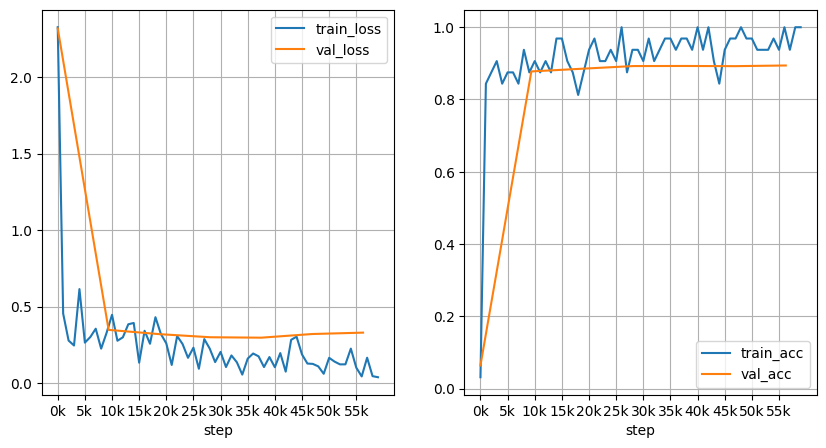

In [41]:
# 注意：损失值不一定在 0~1 之间（交叉熵损失可以大于 1）
def plot_learning_curves(record_dict, sample_step=1000):
    """
    绘制训练过程的学习曲线（损失曲线和准确率曲线）。
    
    参数：
        record_dict  (dict) : training 函数返回的记录字典，含 "train" 和 "val" 两个键
        sample_step  (int)  : 训练集数据的采样间隔（步数），默认每 1000 步取一个点，避免曲线过密
    
    返回值：
        None（直接显示图形）
    """
    # 将训练集记录转为 DataFrame，并以 "step" 列作为行索引
    # pd.DataFrame(list[dict])：将字典列表转为 DataFrame，每个字典变为一行
    # .set_index("step")：将 "step" 列设为行索引，用于 X 轴坐标
    # .iloc[::sample_step]：每隔 sample_step 行取一行（降采样），减少绘图点数
    train_df = pd.DataFrame(record_dict["train"]).set_index("step").iloc[::sample_step]

    # 验证集通常数据量较少（每 eval_step 步才记录一次），不需要降采样
    val_df = pd.DataFrame(record_dict["val"]).set_index("step")

    # 记录训练集最后一步的步数，用于设置 X 轴范围
    last_step = train_df.index[-1]  # 最后一步的全局步数（int）

    # 打印准确率序列（用于调试验证数据是否正确）
    print(train_df['acc'])  # 训练集采样后的准确率，类型：pd.Series
    print(val_df['acc'])    # 验证集准确率，类型：pd.Series

    # 确定子图数量：record_dict 中有几个指标（loss, acc）就画几张子图
    # train_df.columns 返回列名 Index（如 ['loss', 'acc']）
    fig_num = len(train_df.columns)  # 子图数量（int），通常为 2（loss 和 acc）

    # 创建画布：1 行 fig_num 列的子图布局
    # figsize=(5*fig_num, 5)：宽度随子图数量线性增加，高度固定 5 英寸
    # 返回 fig（Figure 对象）和 axs（子图 Axes 数组）
    fig, axs = plt.subplots(1, fig_num, figsize=(5 * fig_num, 5))

    # 遍历每个指标列（如 'loss', 'acc'），分别绘制学习曲线
    for idx, item in enumerate(train_df.columns):
        # 绘制训练集曲线：X 轴为步数，Y 轴为当前指标值（如 loss 或 acc）
        axs[idx].plot(train_df.index, train_df[item], label=f"train_{item}")  # 训练曲线

        # 绘制验证集曲线：验证集每 eval_step 步评估一次，点较稀疏
        axs[idx].plot(val_df.index, val_df[item], label=f"val_{item}")  # 验证曲线

        axs[idx].grid()    # 显示网格线，方便读取数值
        axs[idx].legend()  # 显示图例（区分训练集和验证集曲线）

        # 设置 X 轴刻度：每 5000 步一个刻度
        # range(0, last_step, 5000)：0, 5000, 10000, ...
        axs[idx].set_xticks(range(0, train_df.index[-1], 5000))

        # 设置 X 轴标签：将步数转换为 "0k", "5k", "10k", ... 格式
        # map(func, iterable)：对每个元素应用 lambda 函数
        axs[idx].set_xticklabels(map(lambda x: f"{int(x/1000)}k", range(0, last_step, 5000)))

        axs[idx].set_xlabel("step")  # X 轴标题

    plt.show()  # 渲染并显示图形


# 调用函数，绘制 training 返回的完整学习曲线
# 横坐标：训练步数（steps），纵坐标：损失值 / 准确率
plot_learning_curves(record)  # 显示损失曲线和准确率曲线

## 六、模型评估

训练完成后，在完整验证集（测试集）上对模型进行最终评估，得到模型的泛化性能指标（损失和准确率）。

In [42]:
# 最终评估：在完整验证集（测试集）上计算模型的损失和准确率
# 评估函数内部使用了model.eval()：将模型切换到评估模式
# 评估模式与训练模式的区别：
#   - 禁用 Dropout（所有神经元参与推理，不随机丢弃）
#   - BatchNorm 使用训练期间积累的全局均值和方差（而非当前批次统计量）

# 调用评估函数（内部使用 @torch.no_grad() 禁用梯度计算）
# 参数：model（模型），val_loader（验证集 DataLoader），loss_fct（损失函数）
# 返回值：(float, float) 元组，分别为验证集平均损失和准确率
loss, acc = evaluating(model, val_loader, loss_fct,"测试集",optimizer)  # 在完整测试集上评估

# 格式化打印评估结果
# {loss:.4f}：保留 4 位小数的浮点数格式
# {acc:.4f}：准确率同样保留 4 位小数
print(f"loss:     {loss:.4f}\naccuracy: {acc:.4f}")  # 输出最终损失和准确率

测试集评估: 100%|██████████| 188/188 [00:00<00:00, 471.18it/s, avg_loss=0.3243, avg_acc=0.9015]


loss:     0.3243
accuracy: 0.9015
